# ✨Evaluating spectral reflectance separability✨

This notebook can be used to evaluate spectral separability of point-source spectra using three methods: Hierarchical Cluster Analysis, Spectral Angle Classification, and Random Forest Classification.

## __________________________________________________________________________________________________________________________________________________________
##
## 🔨 Set-up 
Importing modules and data

In [1]:
# Import required scripts
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessing as prep
from scipy.signal import find_peaks as fp
from scipy.signal import savgol_filter
import itertools
from scipy.cluster.hierarchy import fcluster, linkage
import peaks_analysis as pa
import jenkspy
import pywt
import claude_hyper_denoiser as chd
from statsmodels.multivariate.manova import MANOVA


In [2]:
# Magic function to auto-update imported first-party scripts 
%load_ext autoreload
%autoreload 2

In [3]:
# import sys
# !{sys.executable} -m pip install statsmodels

## __________________________________________________________________________________________________________________________________________________________
##
##  🏭 Preprocessing

This section runs the Preprocessor class which imports the data labelled by class name, cleans the data, and filters to desired classes. If a scaler is chosen, it will scale the data accordingly.

In [4]:
# Define preprocessing parameters for hyperspectral data
full_res_path = r"C:\Users\s4770224\Documents\GitHub\Spectral-Analysis\data\MEL_NZ_TAS_spectra.csv"
resample_path = r"data\resampled\Skysat_resampled.csv"
bad_bands_list = list(map(str,(range(753, 769))))
scaler = "minmax"
target_scheme = "farm"
target_sites = None
target_setup = None
start_nm = 460
end_nm = 925

In [5]:
#Run the preprocessing chain (hyperspectral data only)
prepper = prep.PreprocessRefl(data_path = full_res_path,
                              bad_bands = bad_bands_list,
                              scaler = scaler,
                              target_scheme = target_scheme,
                              target_setup = target_setup,
                              target_sites= target_sites,
                              start_nm = start_nm,
                              end_nm = end_nm)
prepper.default_chain()
spectra_prepped = prepper.spectra_norm
labels_prepped = prepper.labels_filtered

Data filtered from 388 to 78 spectra.


# Testing Stats

In [6]:
# Remove noise from all spectra
spectra_no_nan = spectra_prepped.dropna(axis = 1, how = "any")
spectra_quiet = spectra_no_nan.copy()

for row in range(spectra_prepped.shape[0]):
    spectra_quiet.iloc[row, :] = chd.denoise_spectrum(spectra_no_nan.iloc[row, :], wavelet = "db8")

del spectra_no_nan

In [7]:
# Make class means by genus and site from preprocessed data
df = pd.concat([labels_prepped[["Class", "site"]], spectra_quiet], axis = 1)
means = df.groupby(["Class", "site"]).mean().transpose()
means.index = means.index.astype("int64")

In [8]:
# Calculate the derivative of the denoised spectra 
deri_dict = {}
for item in means.items():
    deri_dict[item[0]] = np.gradient(item[1])

In [9]:
# Find all locations for each spectrum where dy/dx == 0 
features_dict = {}
for item in deri_dict.items():
    crossings = pa.find_zero_crossings(item[1])
    features_dict[item[0]] = means.iloc[crossings].index

#Inspect the feature lists
for item in features_dict.items():
   print(f" {item[0]} has {len(item[1])} spectral features")

 ('carpophyllum', 'new_zealand') has 23 spectral features
 ('filamentous_rhodophyte', 'new_zealand') has 13 spectral features
 ('filamentous_rhodophyte', 'tasmania') has 41 spectral features
 ('macrocystis', 'new_zealand') has 9 spectral features
 ('macrocystis', 'tasmania') has 23 spectral features
 ('undaria', 'new_zealand') has 9 spectral features
 ('undaria', 'tasmania') has 17 spectral features


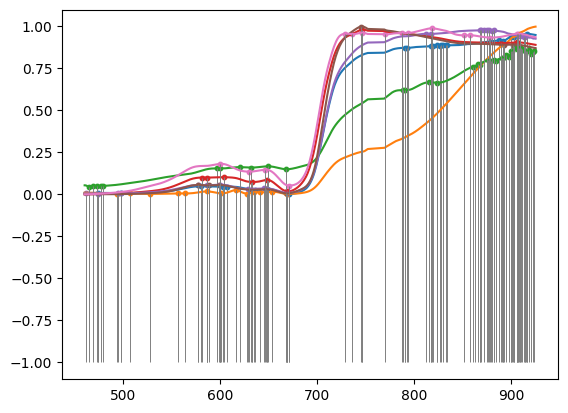

In [10]:
# Plot all the class means
for item in means.items():
    plt.plot(item[1].index, item[1])
    plt.scatter(x = features_dict[item[0]], y = item[1].loc[features_dict[item[0]]], s = 10)
    plt.vlines(x = features_dict[item[0]] , ymin= -1, ymax = item[1].loc[features_dict[item[0]]], linewidth = 0.7, colors= "grey")
plt.savefig("profiles_and_features.svg")

In [11]:
# Aggregate all filtered features into a single list 
features_list = [] 
for item in features_dict.items():
    features_list.append(list(item[1]))
features_list = [x for xs in features_list for x in xs]

In [12]:
# Inspect the agggregated features list
values, counts = np.unique(features_list, return_counts= True)
feature_counts = pd.DataFrame({"nm": values, "count": counts})
feature_counts.head()

,nm,count
0,461,1
1,465,1
2,469,1
3,473,1
4,474,2


In [13]:
# Make new reduced feature spectra sets
reduced_spectra = spectra_quiet.loc[:, list(feature_counts["nm"].astype("str"))]
reduced_spectra = reduced_spectra.transpose()
reduced_means = means.loc[feature_counts["nm"],:]

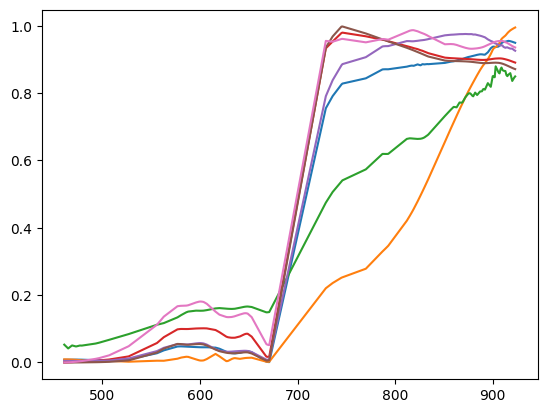

In [14]:
# Plot all reduced dimension class means
for col in reduced_means.columns:
    plt.plot(reduced_means.index, reduced_means.loc[:, col])
plt.show()

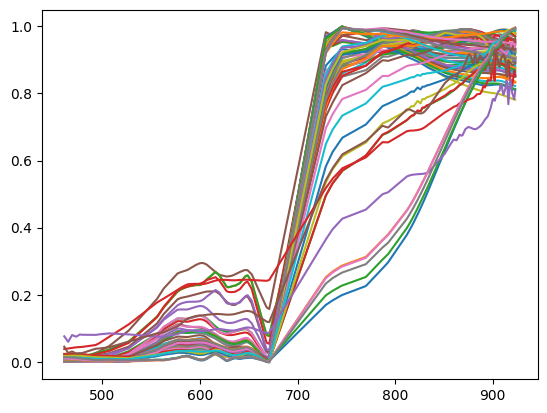

In [15]:
# Plot all reduced dimension spectra
for col in range(reduced_spectra.shape[1]):
    plt.plot(reduced_spectra.index.astype("int"), reduced_spectra.iloc[:, col])
plt.show()

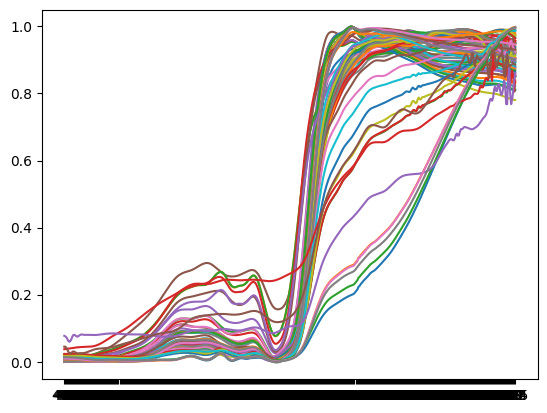

In [16]:
# Plot all denoised spectra
for row in range(spectra_quiet.shape[0]):
    plt.plot(spectra_quiet.columns, spectra_quiet.iloc[row, :])
plt.show()

In [17]:
# Format reduced, denoised spectra for MANOVA and ANOVA
reduced_spectra_labelled = pd.concat([labels_prepped[["Class", "site"]], reduced_spectra], axis = 1)

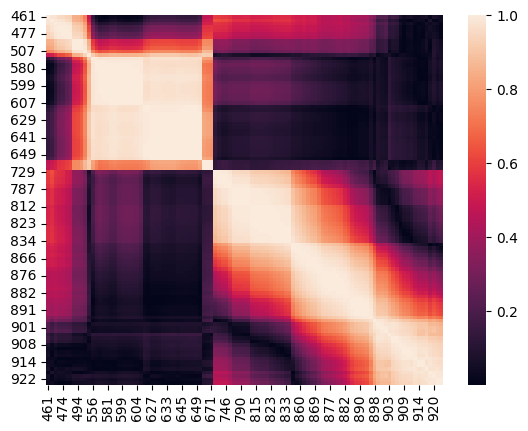

In [18]:
corr_mat = reduced_spectra.transpose().corr()
sns.heatmap(abs(corr_mat))
plt.savefig("correlation_matrix.svg")

In [19]:
# Filter features into groups by correlation threshold
# Then pick representative wavelength for that feature
features_id = []
start_nm = []
end_nm = []
i = 0
threshold = 0.98
corr_mat = abs(corr_mat)
for n in range(0, corr_mat.shape[0]):
    # check if any correlation below threshold in features i to n
    if any(np.sum(corr_mat.iloc[i:n, i:n] < threshold)):
        r = n-1
        # Find most representative feature as most correlated
        feat_num = np.argmax(np.sum(corr_mat.iloc[i:r, i:r], axis = 0)) + i
        features_id.append(int(corr_mat.index[feat_num]))
        print(f"Wavelength {corr_mat.index[feat_num]} identified as representative of {corr_mat.index[i]} to {corr_mat.index[r]}.")
        start_nm.append(int(corr_mat.index[i]))
        end_nm.append(int(corr_mat.index[r]))
        i = n
    else:
        ""

print(f"\n {len(features_id)} representative features found.")

Wavelength 461 identified as representative of 461 to 465.
Wavelength 473 identified as representative of 469 to 479.
Wavelength 494 identified as representative of 493 to 507.
Wavelength 527 identified as representative of 527 to 556.
Wavelength 596 identified as representative of 563 to 616.
Wavelength 645 identified as representative of 620 to 668.
Wavelength 669 identified as representative of 669 to 729.
Wavelength 746 identified as representative of 736 to 787.
Wavelength 812 identified as representative of 788 to 828.
Wavelength 833 identified as representative of 830 to 851.
Wavelength 863 identified as representative of 857 to 869.
Wavelength 877 identified as representative of 872 to 882.
Wavelength 889 identified as representative of 884 to 895.
Wavelength 900 identified as representative of 898 to 902.
Wavelength 903 identified as representative of 903 to 907.
Wavelength 910 identified as representative of 908 to 914.
Wavelength 915 identified as representative of 915 to 91

c:\Users\s4770224\Documents\GitHub\Spectral-Analysis\separability_venv\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


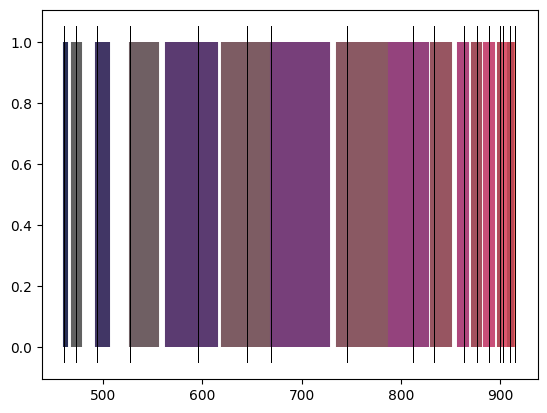

In [20]:
# Plot the feature ranges and the most representative bands chosen for analysis
colours_ordered = {
    1: "#292f56",
    2: "#413665",
    3: "#5b3b71",
    4: "#773f7a",
    5: "#94437d",
    6: "#af477d",
    7: "#c84e78",
    8: "#de586f",
    9: "#ef6764",
    10: "#fc7a56",
    11: "#ff9047",
    12: "#ffa836",
    13: "#fdc124", 
    14: "#f0db19",
    15: "#616161",
    16: "#6f5f63",
    17: "#7d5c63",
    18: "#8a5963",
    19: "#975561",
    20: "#a3515e",
    21: "#af4c59",
    22: "#ba4754",
    23: "#c5414e",
    24: "#cf3a46",
    25: "#d9333d",
    26: "#e12b33",
    27: "#e92228",
    28: "#f01919",}

colours_mixed = {
    1: "#292f56",
    2: "#616161",
    3: "#413665",
    4: "#6f5f63",
    5: "#5b3b71",
    6: "#7d5c63",
    7: "#773f7a",
    8: "#8a5963",
    9: "#94437d",
    10: "#975561",
    11: "#af477d",
    12: "#a3515e",
    13: "#c84e78",
    14: "#af4c59",
    15: "#de586f",
    16: "#ba4754",
    17: "#ef6764",
    18: "#c5414e",
    19: "#fc7a56",
    20: "#cf3a46",
    21: "#ff9047",
    22: "#d9333d",
    23: "#ffa836",
    24: "#e12b33",
    25: "#fdc124", 
    26: "#e92228",
    27: "#f0db19",
    28: "#f01919"}
    
counter= 1 
for a, b in zip (start_nm, end_nm):
    plt.vlines(x = list(range(a, b)), ymin = 0, ymax = 1, colors = colours_mixed[counter])
    counter +=1
for feature in features_id:
    plt.vlines(x = features_id, ymin = -0.05, ymax = 1.05, colors = 'black', linewidth = 0.7)
    plt.savefig("representative_features.svg")
plt.show()

In [21]:
# Make spectral data reduced to only representative features
features_id_str = [str(x) for x in features_id]
redred = spectra_prepped.loc[:, features_id_str]
redred.shape

(78, 17)

In [22]:
# Make data ingestible for MANOVA and ANOVA
comp_labels = labels_prepped["Class"] + "_" + labels_prepped["site"]
labels_array = comp_labels.astype('category').cat.codes.astype(float)

# MANOVA
maov = MANOVA(redred, labels_array) 
print(maov.mv_test())

#Access all digits in MANOVA results
maov_df = pd.DataFrame(maov.mv_test().results["x0"]["stat"])
maov_df.loc["Wilks' lambda", "Pr > F"]
for index in maov_df.index:
    print(maov_df.loc[index, "Pr > F"])

                  Multivariate linear model
                                                             
-------------------------------------------------------------
           x0           Value   Num DF  Den DF F Value Pr > F
-------------------------------------------------------------
          Wilks' lambda 0.0929 17.0000 61.0000 35.0192 0.0000
         Pillai's trace 0.9071 17.0000 61.0000 35.0192 0.0000
 Hotelling-Lawley trace 9.7595 17.0000 61.0000 35.0192 0.0000
    Roy's greatest root 9.7595 17.0000 61.0000 35.0192 0.0000

4.2372466283289145e-25
4.2372466283289145e-25
4.237246628328902e-25
4.2372466283289145e-25
